In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents

import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.INFO)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

In [2]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.WARNING)
logging.getLogger("TD3-Agent").setLevel(logging.WARNING)

 # Environment
env_id = 'Pendulum-v1'
run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

# Agent
agent_id = 'KerasTD3-v0'
logdir = glob.glob(f'./results/Pendulum/*{agent_id}*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

checkpoints = sorted(glob.glob(f'{logdir}/models/epoch_*'))
agent.model_load_path = checkpoints[-1]
print(os.path.basename(agent.model_load_path))
agent.load()

2024-07-01 11:00:22,397 INFO:RunOpenAI:Running env: Pendulum-v1


2024-07-01 11:00:22,402 INFO:RunOpenAI:Size of State Space ->  3
2024-07-01 11:00:22,402 INFO:RunOpenAI:Size of Action Space ->  1
2024-07-01 11:00:22,402 INFO:RunOpenAI:Max Value of Action ->  2.0
2024-07-01 11:00:22,403 INFO:RunOpenAI:Min Value of Action ->  -2.0
2024-07-01 11:00:22,404 ERROR:CfgLogger:Problem with key request using None
2024-07-01 11:00:22,408 INFO:Buffer:Buffer config saved successfully
2024-07-01 11:00:22,421 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 11:00:22,426 ERROR:Actor:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 11:00:22,447 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-07-01 11:00:22,450 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.

Attempting to load jlab_opt_control.agents with KerasTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
epoch_249


In [3]:
import matplotlib.pyplot as plt

def plot_pendulum_space(ax, actions, critic_values, theta, omega, 
                        vmin=-200, vmax=0, label='Critic value'):
        r = 1 + omega / 16. # Radius corresponds to angular velocity
        t = 5 * np.abs(actions)# Size corresponds to torque magnitude

        x = -r * np.sin(theta)
        y = r * np.cos(theta)

        # Torque parallel to angular velocity
        mask = np.sign(actions * omega) >= 0
        im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask],
                         vmin=vmin, vmax=vmax,
                         cmap='viridis', marker='^', label='Accelerating torque')

        # Torque antiparallel to angular velocity
        mask = np.sign(actions * omega) < 0
        im1 = ax.scatter(x[mask], y[mask], c=critic_values[mask], s=t[mask],
                         vmin=vmin, vmax=vmax,
                         cmap='viridis', marker='v', label='Decelerating torque')
        
        plt.colorbar(im1, ax=ax, label=label)

        # Plot circle for pendulum path
        t = np.linspace(0, 2*np.pi, 100)
        ax.plot(np.cos(t), np.sin(t), color='black', zorder=2,
                label='Pendulum path')
        
        # Plot contours for angular velocity
        x = np.linspace(-1.5, 1.5, 100)
        y = np.linspace(-1.5, 1.5, 100)
        X, Y = np.meshgrid(x, y)
        R = np.sqrt(X**2 + Y**2)
        O = (R - 1) * 16
        O[np.abs(O) > 8] = np.nan

        im2 = ax.pcolormesh(X, Y, O, cmap='bwr', alpha=0.7, zorder=-2)
        plt.colorbar(im2, ax=ax, label='Angular velocity (rad/s)')

        ax.set(xticks=[], yticks=[], aspect='equal')
        ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
                  ncol=2, framealpha=0)
        
        return ax

# TD3 Model

Text(0.5, 0.98, 'TD3 Agent')

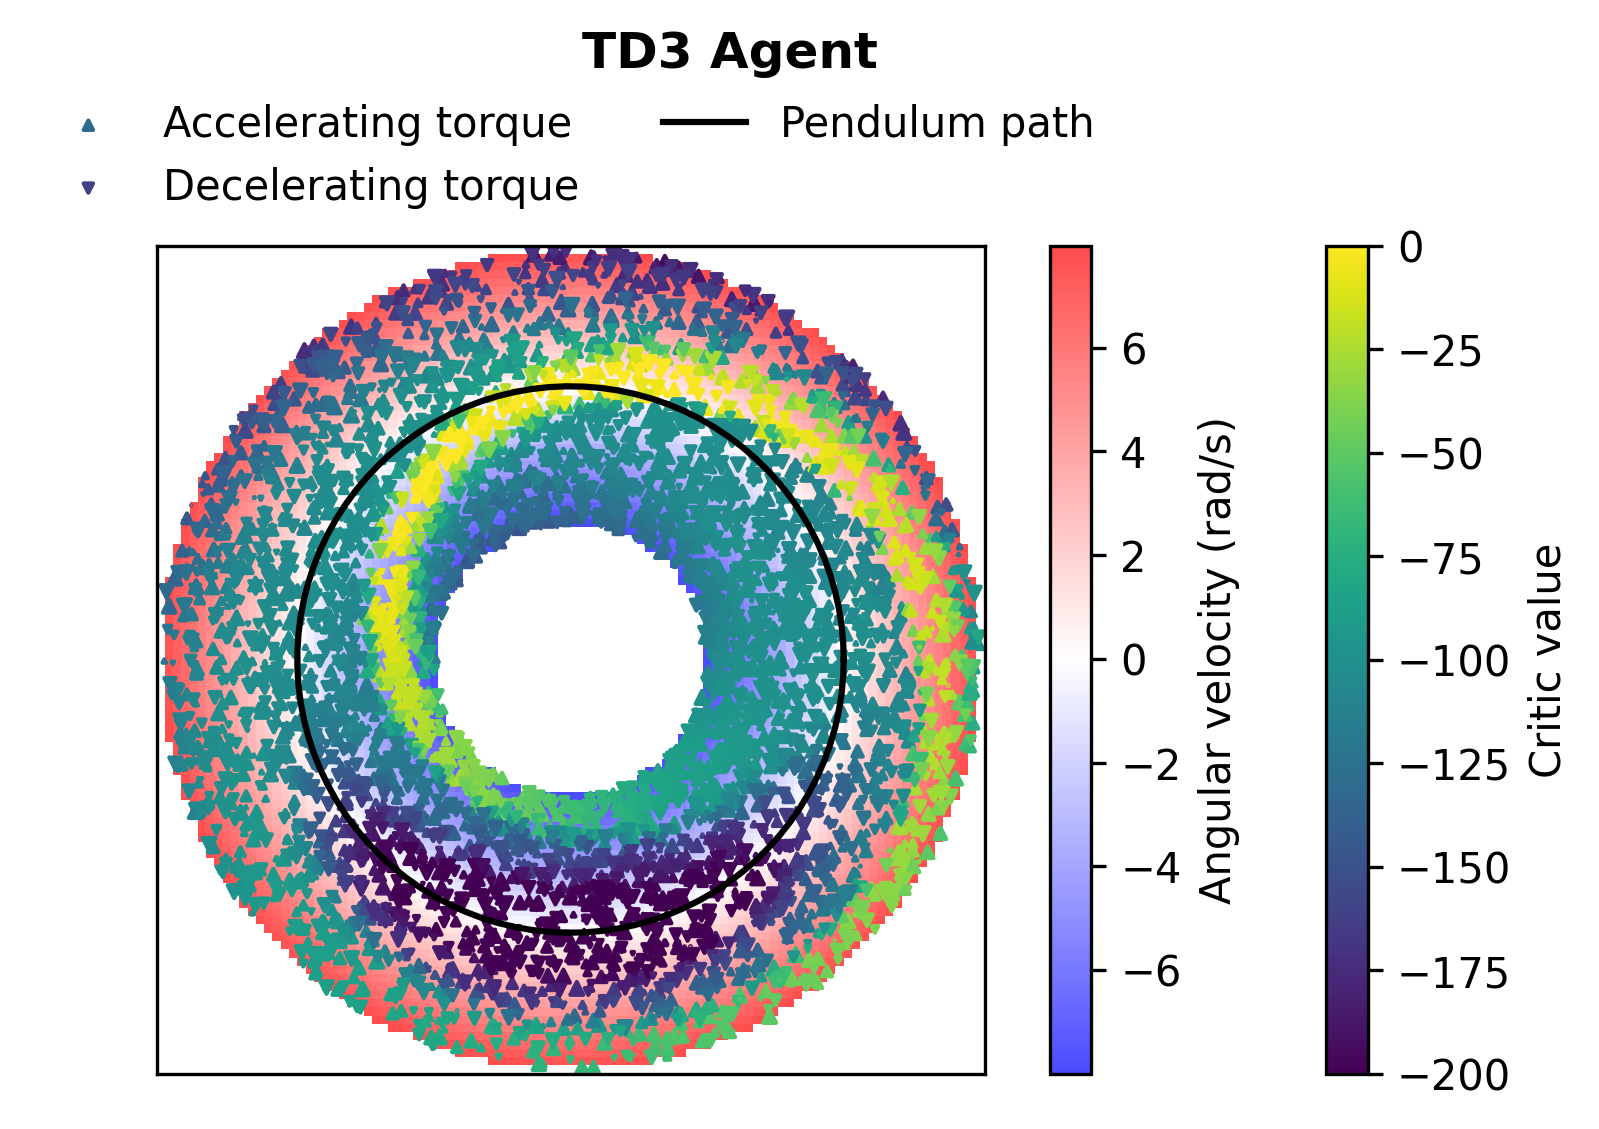

In [39]:
n_train = 5000

# Training
theta = np.random.uniform(low=0, high=2*np.pi, size=(n_train, 1))
#theta = np.random.uniform(low=-np.pi, high=np.pi, size=(n_train, 1))
omega = np.random.uniform(low=-8, high=8, size=(n_train, 1))
states = np.concatenate([np.cos(theta), np.sin(theta), omega], axis=1)
actions = np.random.uniform(low=env.action_space.low, high=env.action_space.high, size=(n_train, env.action_space.shape[0]))

test_theta = np.random.uniform(low=0, high=2*np.pi, size=(n_train, 1))
#test_theta = np.random.uniform(low=-np.pi, high=np.pi, size=(n_train, 1))
test_omega = np.random.uniform(low=-8, high=8, size=(n_train, 1))
test_states = np.concatenate([np.cos(test_theta), np.sin(test_theta), test_omega], axis=1)
test_actions = np.random.uniform(env.action_space.low, env.action_space.high, size=(n_train, env.action_space.shape[0]))

critic_values = agent.critic_model1(states, actions, training=False).numpy()
actor_values = agent.actor_model(states, training=False).numpy()

fig, ax = plt.subplots(1, 1, dpi=300, figsize=(7, 4))
plot_pendulum_space(ax, actions, critic_values, theta, omega, label='Critic value')
          
fig.subplots_adjust(top=0.8)
fig.suptitle('TD3 Agent', fontweight='bold')

# SINDy with $(x, y, \omega, \tau)$

/Users/jcolen/miniconda3/envs/jlab_opt_control_env/lib/python3.9/site-packages/pysindy/optimizers/sr3.py:390: ConvergenceWarning: SR3._reduce did not converge after 30 iterations.
  warnings.warn(


Q = -80.0 1 + 51.1 x + -51.4 x^2 + -28.6 y^2 + 1.4 w^2 + 40.3 x^3 + -10.8 x y w + -2.9 x w^2 + -22.3 x^4 + -29.1 x^2 y^2 + 0.9 x^2 w^2 + 0.4 y^4 + -4.3 y^3 w + 0.6 y^2 w^2 + 8.5 x^5 + 31.8 x^3 y^2 + -5.7 x^3 y w + -1.9 x^3 w^2 + -5.1 x y^3 w + -1.1 x y^2 w^2 + 0.4 x y w^3
R2 score is 0.839
Q = -9507554950.240 1 + 49.905 x + -0.630 y + 0.419 w + 1.287 T + 7130666101.675 x^2 + -0.319 x y + 0.311 x w + 0.880 x T + 7130666124.127 y^2 + -2.851 y w + -2.024 y T + 1.443 w^2 + 0.448 w T + -0.090 T^2 + 37.200 x^3 + -0.120 x^2 y + 0.305 x^2 w + 0.601 x^2 T + 12.704 x y^2 + -10.874 x y w + -0.228 x y T + -2.931 x w^2 + -1.021 x w T + 0.406 x T^2 + -0.504 y^3 + 0.115 y^2 w + 0.687 y^2 T + -0.116 y w^2 + -0.067 y w T + 0.306 y T^2 + -0.051 w^3 + -0.031 w^2 T + -0.097 w T^2 + -0.884 T^3 + 2376888694.992 x^4 + -0.529 x^3 y + 0.148 x^3 w + 0.027 x^3 T + 4753777406.683 x^2 y^2 + -0.137 x^2 y w + -1.160 x^2 y T + 0.859 x^2 w^2 + 0.220 x^2 w T + -0.109 x^2 T^2 + 0.210 x y^3 + 0.162 x y^2 w + 0.853 x y^2 

Text(0.5, 0.98, 'SINDy $(x, y, \\omega, \\tau)$: 126 terms')

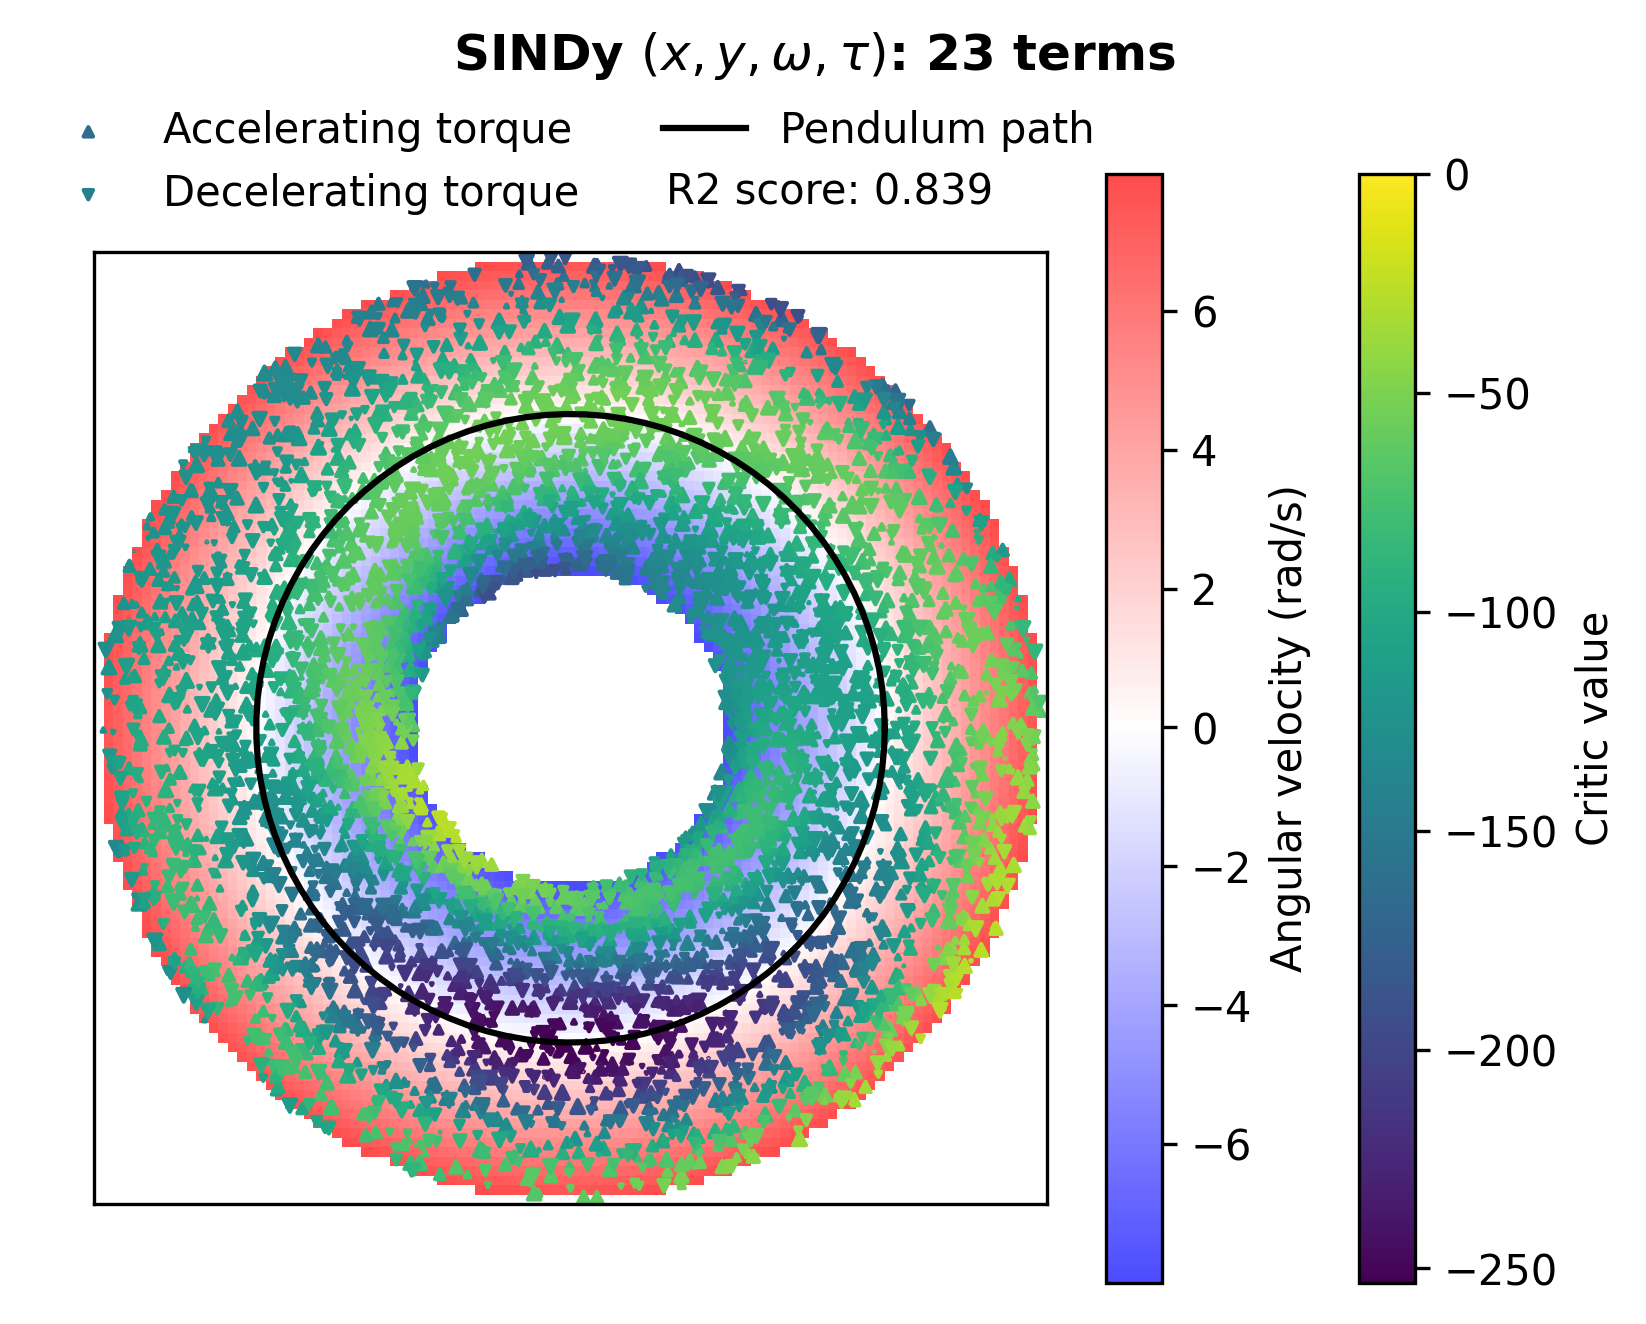

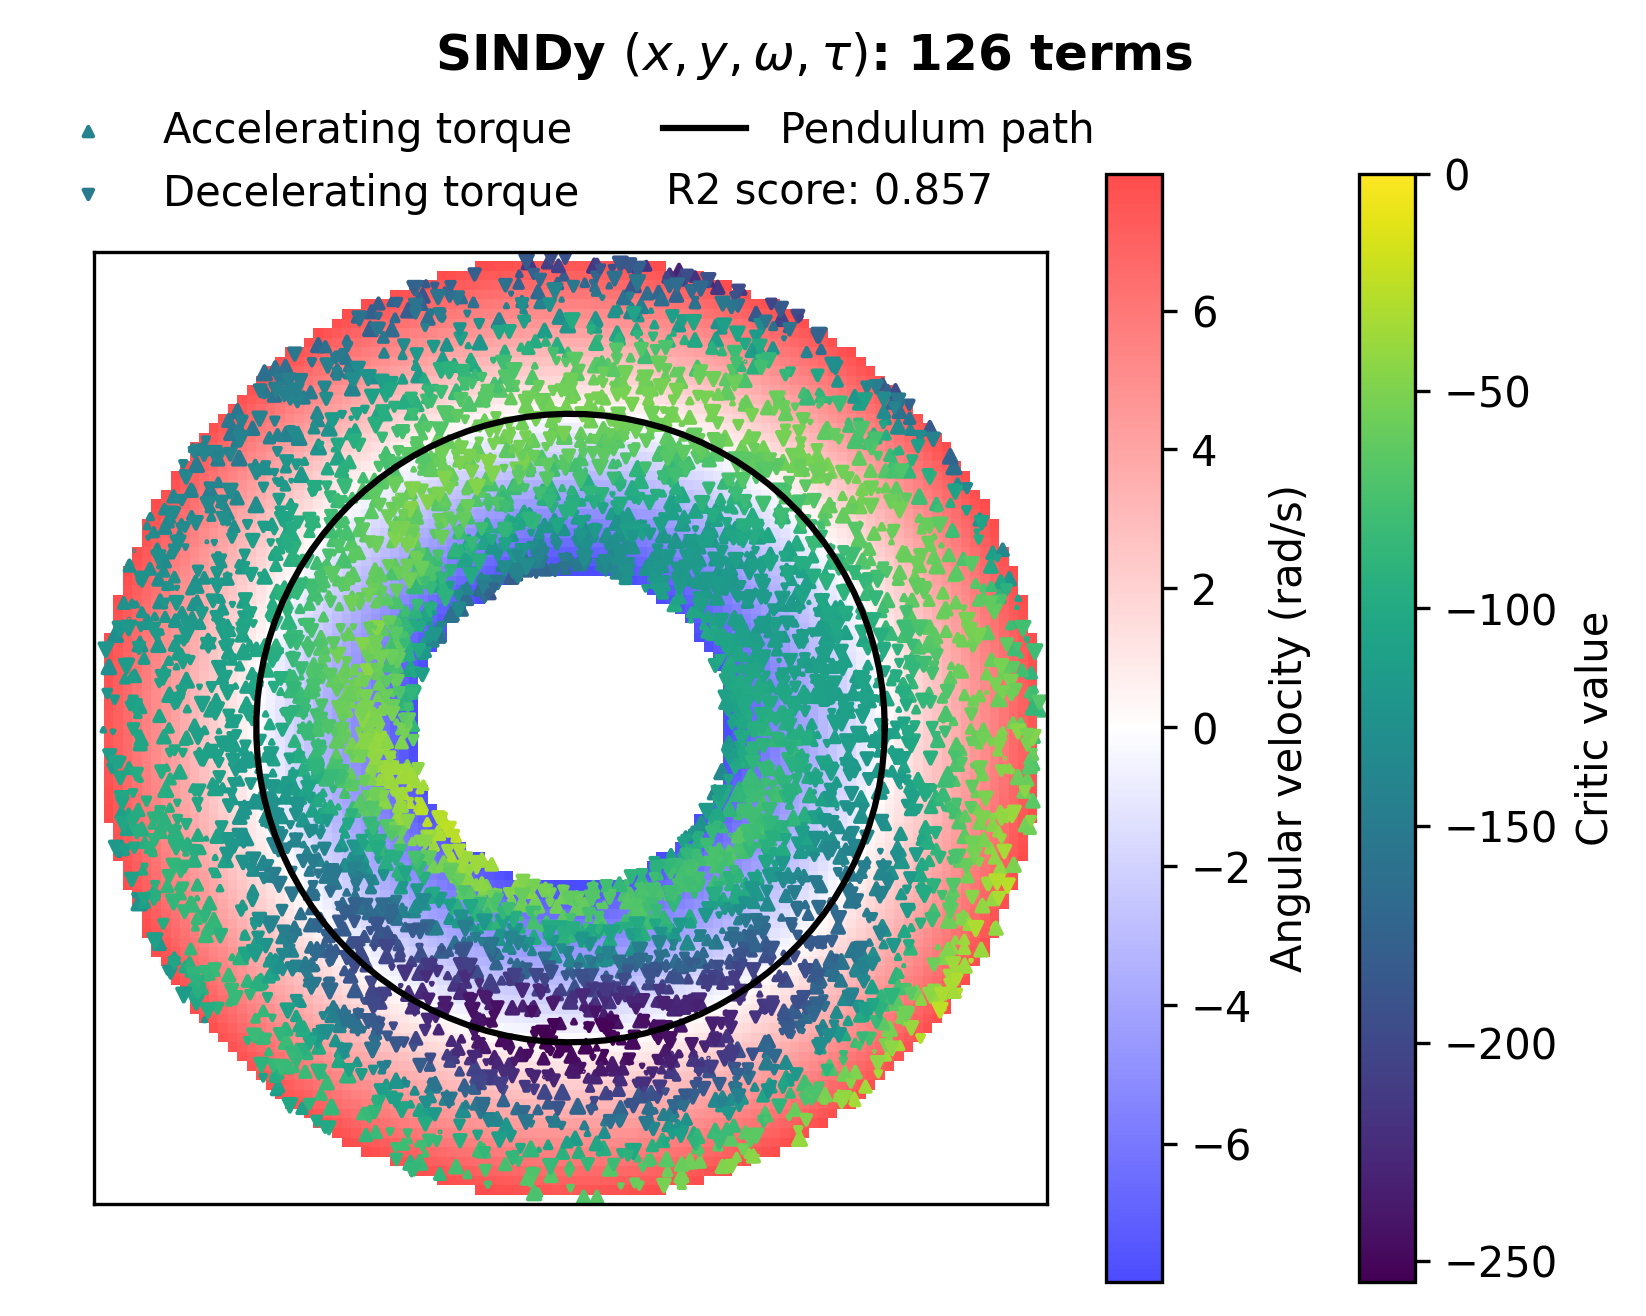

In [56]:
import matplotlib.pyplot as plt
import pysindy as ps

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

poly_library = ps.PolynomialLibrary(degree=5, include_bias=True, include_interaction=True)

sindy = ps.SINDy(
    feature_library=poly_library,
    optimizer=ps.SR3(threshold=2e1, nu=1e-2, thresholder='L1', normalize_columns=True),
    feature_names=['x', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)
plot_pendulum_space(ax, actions, sindy_values, theta, omega, label='Critic value', vmax=0, vmin=None)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

sindy = ps.SINDy(
    feature_library=poly_library,
    optimizer=ps.STLSQ(threshold=0, alpha=1, normalize_columns=True),
    feature_names=['x', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)
plot_pendulum_space(ax, actions, sindy_values, theta, omega, label='Critic value', vmax=0, vmin=None)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# SINDy with $(\theta, \omega, \tau)$

(5000, 3) (5000, 1) (5000, 1) (5000, 1)
(5000, 3) (5000, 1)
Q = -59.4 1 + 24.4 th + -78.7 th^2 + -1.8 w^2 + -2.7 T^2 + 24.0 th^3 + 3.8 th w^2 + 0.3 th T^2 + -1.9 th^4 + -0.6 th^2 w^2 + 0.2 T^4
R2 score is 0.629
Q = -32.9 1 + -147.0 th + -9.5 w + 4.2 T + 262.1 th^2 + 2.9 th w + -15.5 th T + -4.0 w^2 + -2.0 w T + 0.3 T^2 + -221.1 th^3 + 1.1 th^2 w + 10.2 th^2 T + 2.0 th w^2 + 3.0 th w T + -0.9 th T^2 + 0.3 w^3 + -0.1 w^2 T + -0.4 w T^2 + 1.7 T^3 + 75.2 th^4 + -0.7 th^3 w + -2.8 th^3 T + 2.7 th^2 w^2 + -0.9 th^2 w T + 0.5 th^2 T^2 + -0.3 th w^3 + 0.2 th w^2 T + -0.2 th w T^2 + 0.2 th T^3 + 0.1 w^2 T^2 + 0.3 w T^3 + -1.2 T^4 + -11.0 th^5 + 0.1 th^4 w + 0.4 th^4 T + -0.9 th^3 w^2 + 0.1 th^3 w T + -0.1 th^3 T^2 + 0.1 th^2 w^3 + -0.1 th^2 w^2 T + 0.1 th^2 w T^2 + -0.4 th^2 T^3 + -0.1 th w^4 + 0.1 th w T^3 + -0.5 T^5 + 0.6 th^6 + 0.1 th^4 w^2 + 0.1 th T^5 + -0.1 w T^5 + 0.2 T^6
R2 score is 0.818


Text(0.5, 0.98, 'SINDy $(\\theta, \\omega, \\tau)$: 84 terms')

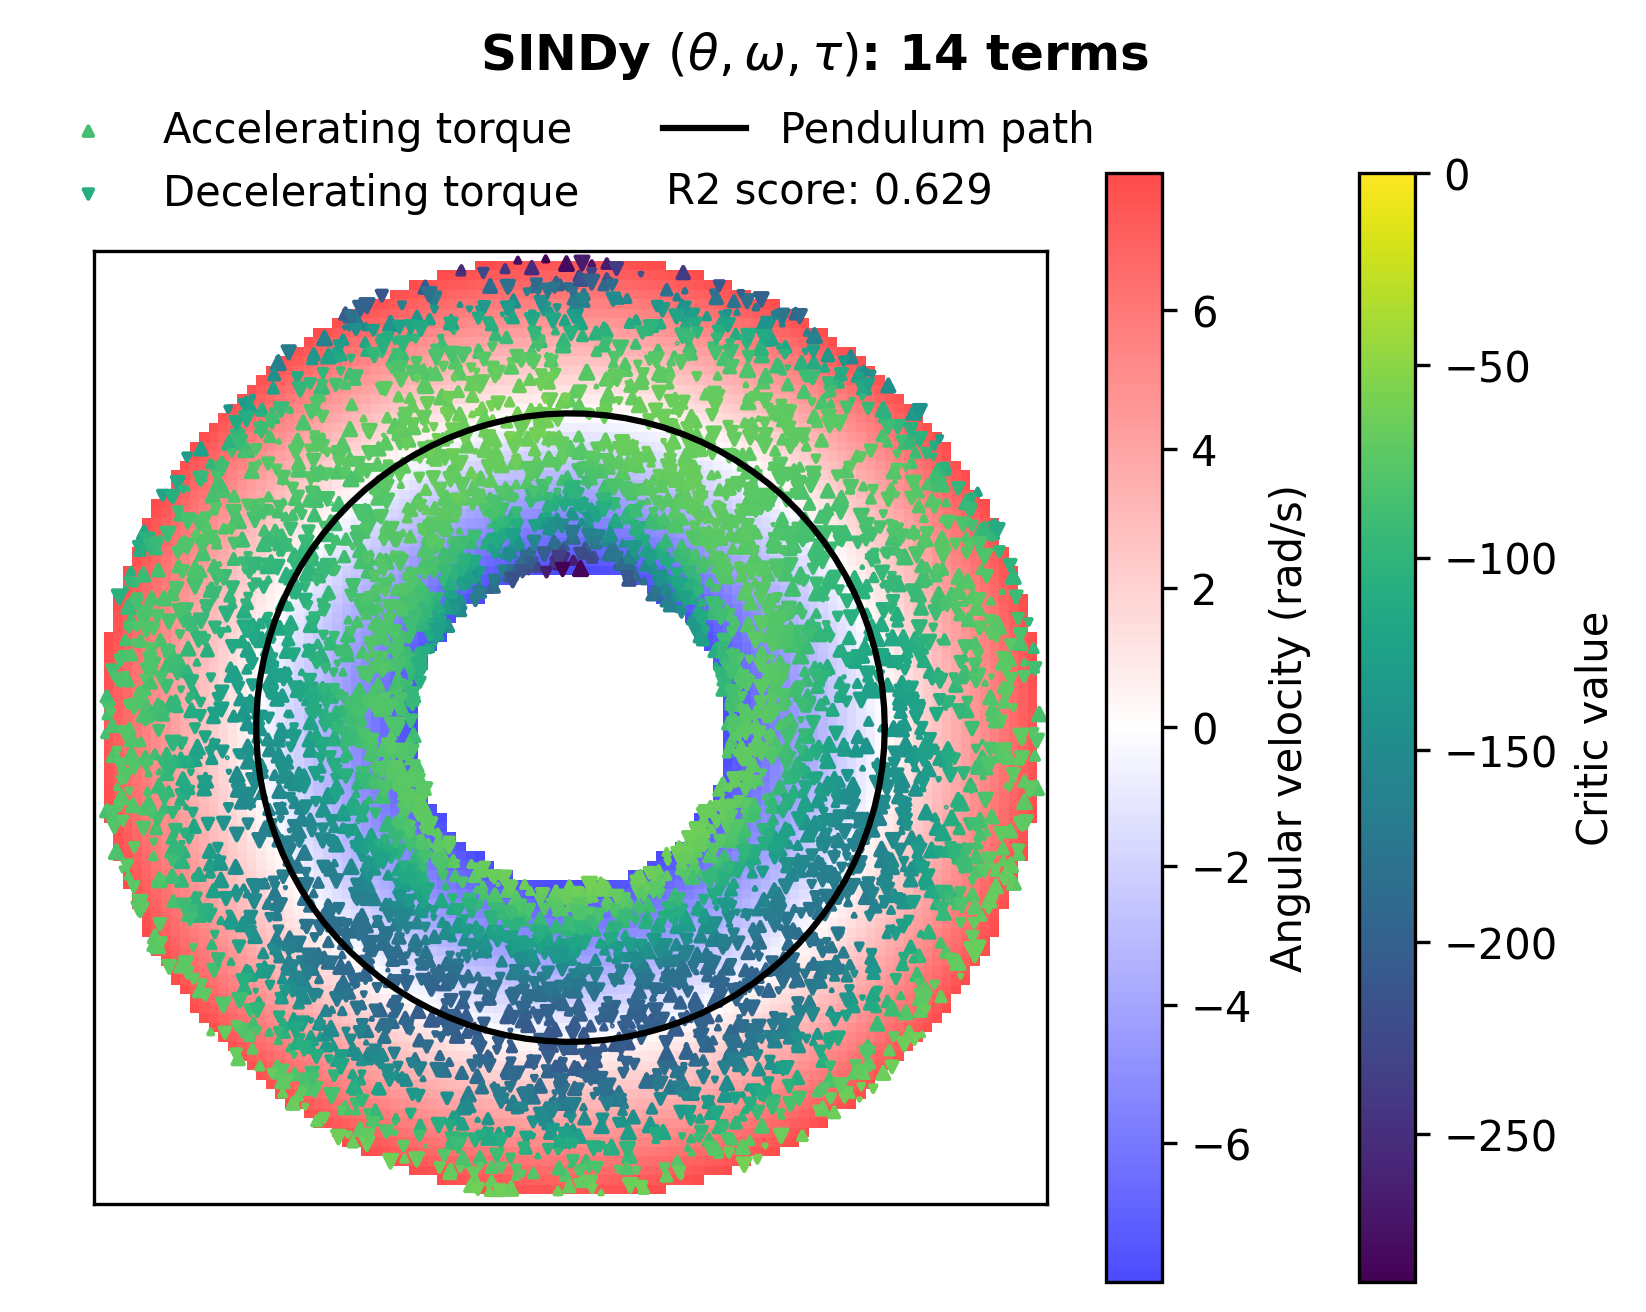

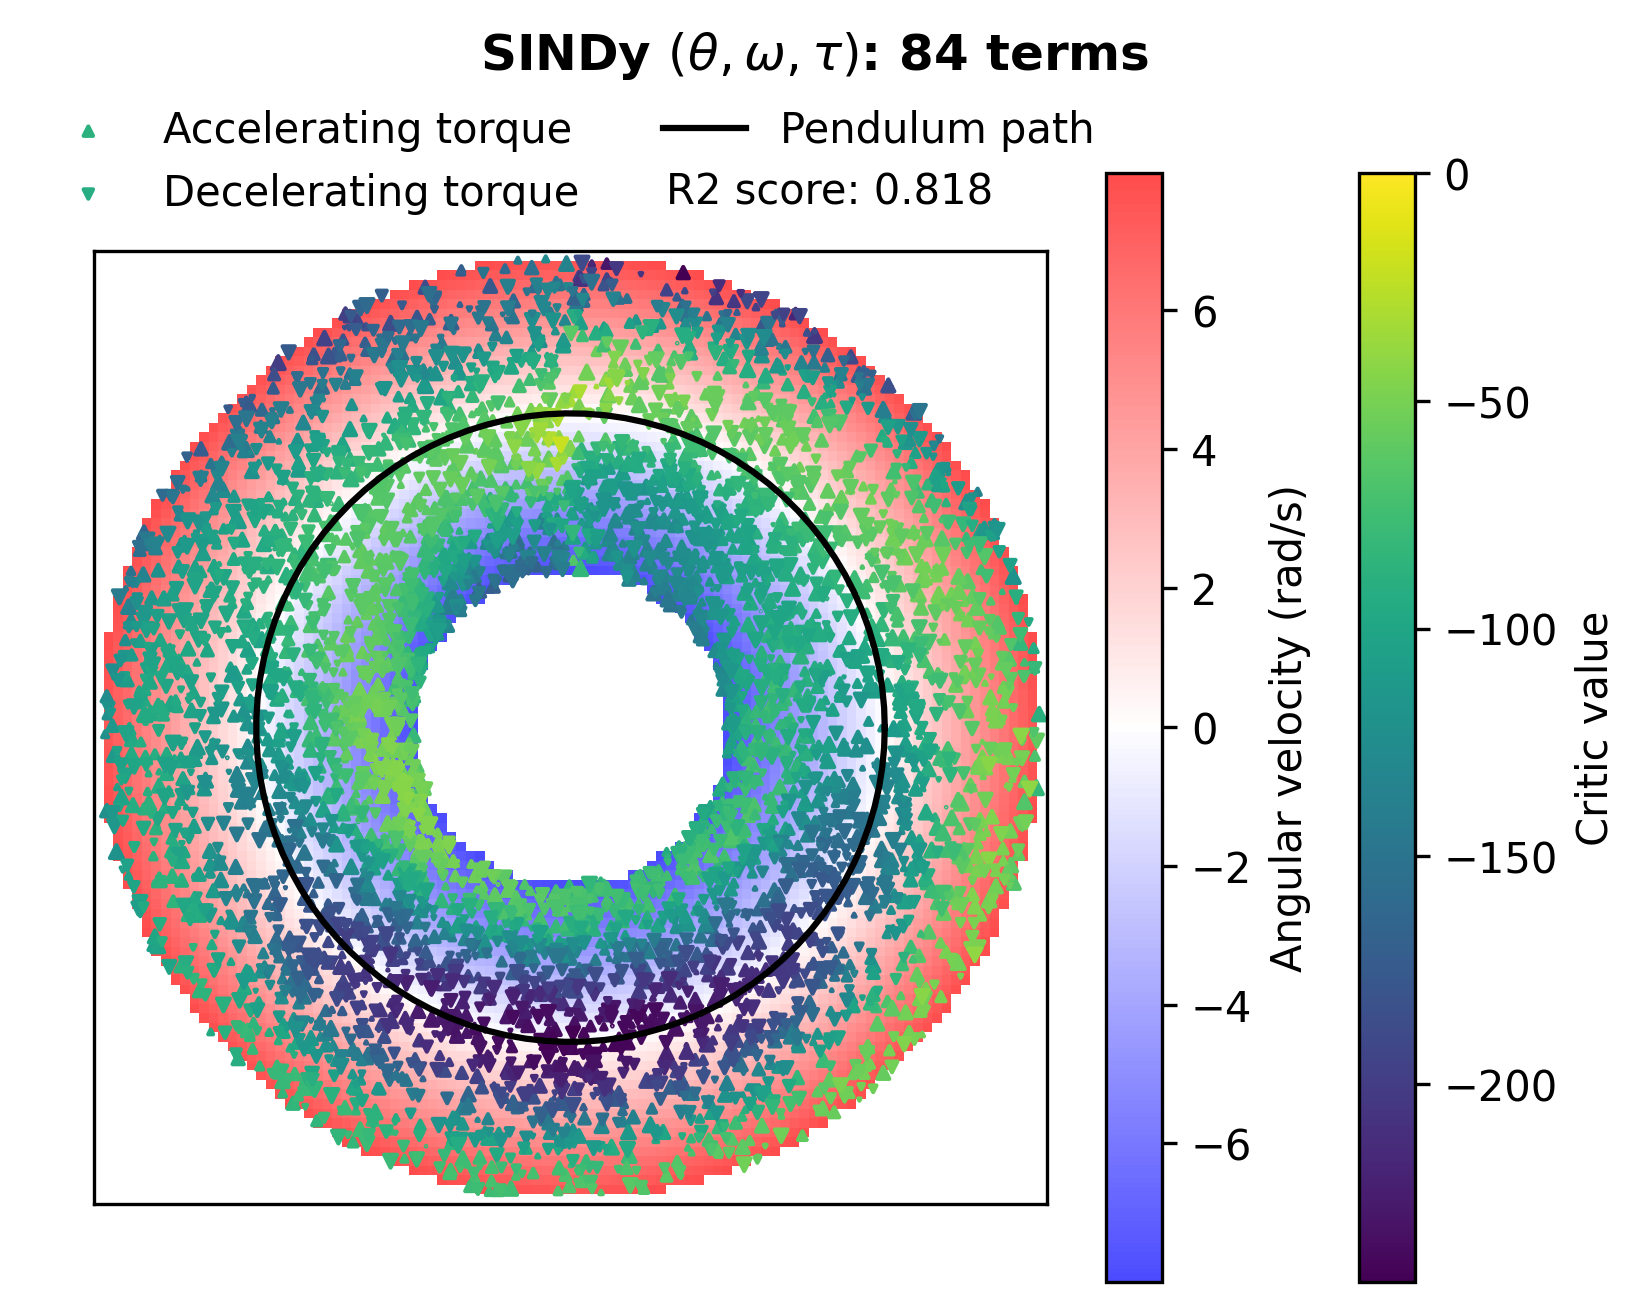

In [18]:
# Using theta instead of x and y

import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=4, include_bias=True, include_interaction=True),
    optimizer=ps.STLSQ(threshold=1e0, alpha=1e3, normalize_columns=True),
    #optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)
plot_pendulum_space(ax, actions, sindy_values, theta, omega, label='Critic value', vmax=0, vmin=None)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=6, include_bias=True, include_interaction=True),
    optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q', precision=1)
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)
plot_pendulum_space(ax, actions, sindy_values, theta, omega, label='Critic value', vmax=0, vmin=None)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# SINDy with $(\theta, x, y, \omega, \tau)$

(5000, 3) (5000, 1) (5000, 1) (5000, 1)
(5000, 5) (5000, 1)
Q = -60473457.083 1 + 130860005.445 th + 61942017.932 x, + 30565282.031 y + 38490505.077 w + 102097334.304 T + -92891707.566 th^2 + -20894697.005 th x, + 9200664.820 th y + 183731405.240 th w + 642948881.706 th T + 16313009.203 x,^2 + -21996931.473 x, y + -141429268.066 x, w + -291265779.898 x, T + 1811746.078 y^2 + 96567758.791 y w + 384926533.333 y T + 59434993.025 w^2 + 217958732.994 w T + 2350260040.049 T^2 + -132381491.247 th^3 + 117325563.227 th^2 x, + 11947758.385 th^2 y + 845120793.950 th^2 w + 939428557.112 th^2 T + 13406396.957 th x,^2 + 47347860.496 th x, y + 168758641.253 th x, w + -575195723.324 th x, T + -83344167.130 th y^2 + -59006511.385 th y w + 213078820.861 th y T + -69116360.848 th w^2 + -59563351.750 th w T + 1196565155.973 th T^2 + -50214838.735 x,^3 + 14541143.837 x,^2 y + -337284328.128 x,^2 w + -458724972.738 x,^2 T + 87426485.619 x, y^2 + -163102836.889 x, y w + -73937177.448 x, y T + 96162983.635 x,

Text(0.5, 0.98, 'SINDy $(\\theta, x, y, \\omega, \\tau)$: 462 terms')

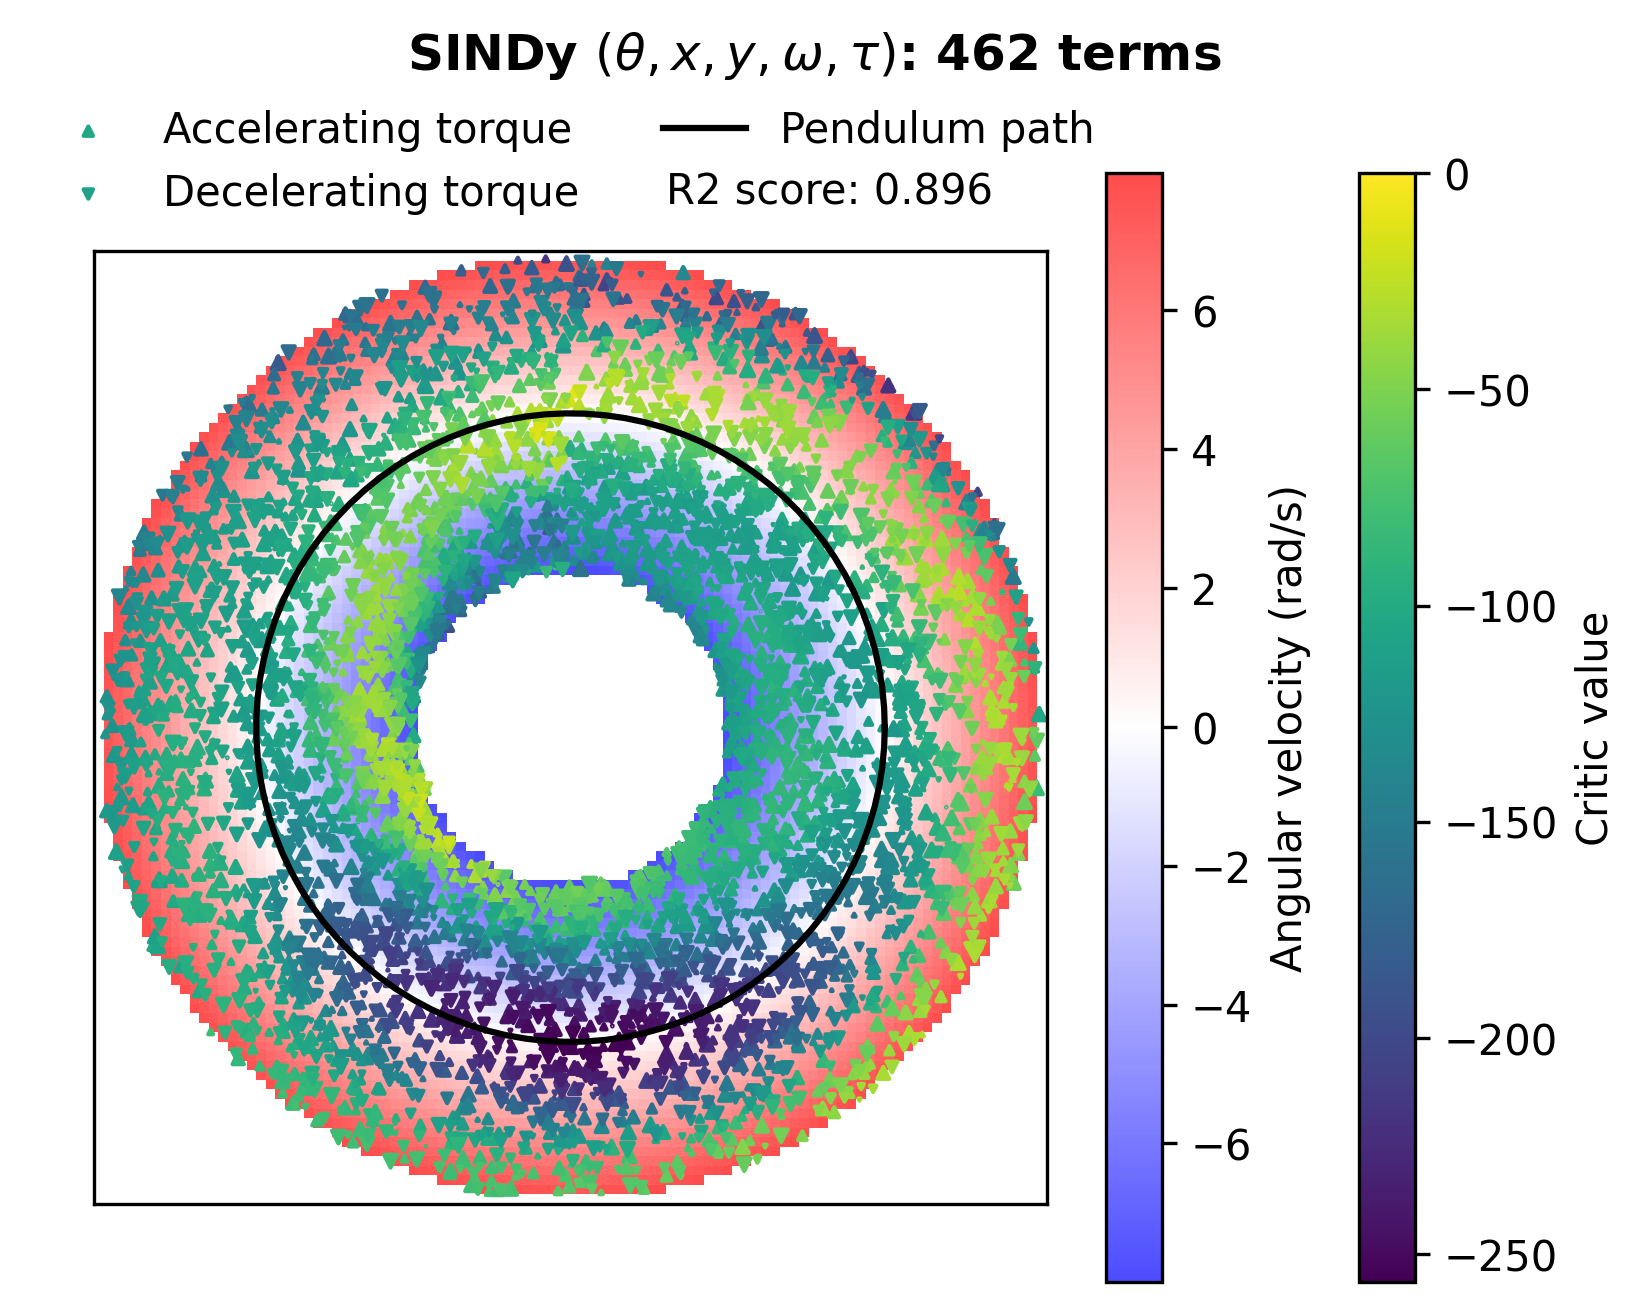

In [15]:
# Using theta and x and y

import matplotlib.pyplot as plt
import pysindy as ps

print(states.shape, actions.shape, actor_values.shape, critic_values.shape)

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=6, include_bias=True, include_interaction=True),
    #optimizer=ps.STLSQ(threshold=2e-1, alpha=5e3, normalize_columns=True),
    optimizer=ps.STLSQ(threshold=0, alpha=10, normalize_columns=True),
    feature_names=['th', 'x,', 'y', 'w', 'T']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

fig, ax = plt.subplots(1, 1, dpi=300)
plot_pendulum_space(ax, actions, sindy_values, theta, omega, label='Critic value', vmax=0, vmin=None)

test_score = sindy.score(x=test_inputs, x_dot=test_targets)
print(f'R2 score is {test_score:.3f}')
ax.text(0.6, 1.05, f'R2 score: {test_score:.3f}', transform=ax.transAxes)
num_terms = np.count_nonzero(sindy.coefficients())
fig.suptitle(f'SINDy $(\\theta, x, y, \\omega, \\tau)$: {num_terms} terms', fontweight='bold')

# Parameter sweep results on SINDy

In [343]:
# Let's do a parameter sweep
import pandas as pd
results = pd.DataFrame(columns=['degree', 'interaction', 'score', 'num_terms', 'library'])

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

threshold=0
alpha=10

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$x, y, \\omega, \\tau$']

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, \\omega, \\tau$']

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True, False]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, x, y, \\omega, \\tau$']

results


(10000, 4) (10000, 1)
(10000, 3) (10000, 1)
(10000, 5) (10000, 1)


,degree,interaction,score,num_terms,library
0,1,True,0.139724,5,"$x, y, \omega, \tau$"
1,1,False,0.139724,5,"$x, y, \omega, \tau$"
2,2,True,0.588561,15,"$x, y, \omega, \tau$"
3,2,False,0.219352,9,"$x, y, \omega, \tau$"
4,3,True,0.790774,35,"$x, y, \omega, \tau$"
5,3,False,0.221545,13,"$x, y, \omega, \tau$"
6,4,True,0.814212,70,"$x, y, \omega, \tau$"
7,4,False,0.230026,17,"$x, y, \omega, \tau$"
8,5,True,0.892020,126,"$x, y, \omega, \tau$"
9,5,False,0.229235,21,"$x, y, \omega, \tau$"


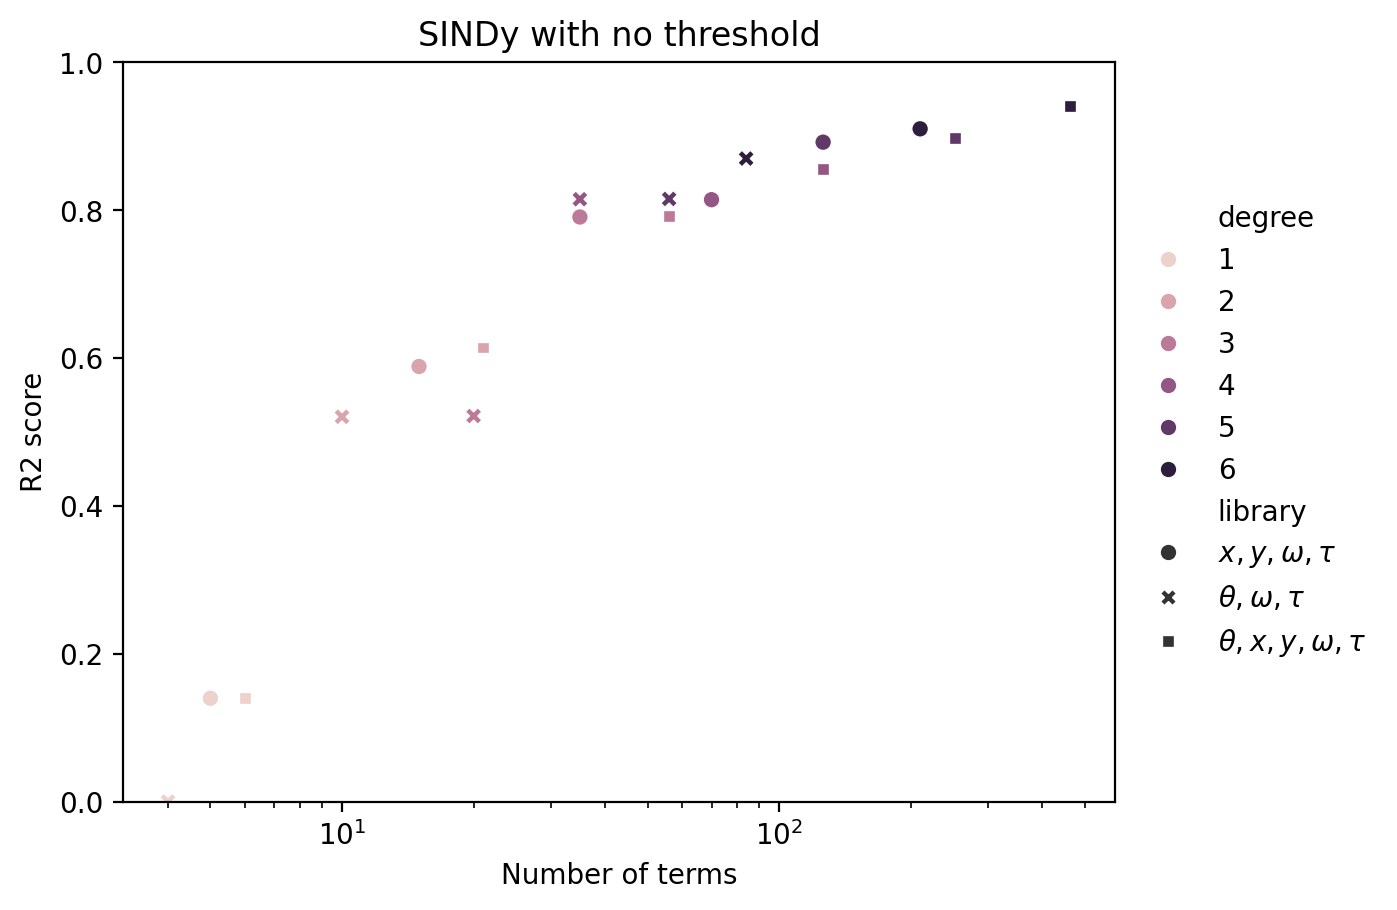

In [344]:
import seaborn as sns
plt.rcParams['figure.dpi'] = 200
p = sns.scatterplot(
    data=results[results.interaction],
    x='num_terms',
    y='score',
    hue='degree',
    style='library',
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score', title='SINDy with no threshold')
sns.move_legend(p, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

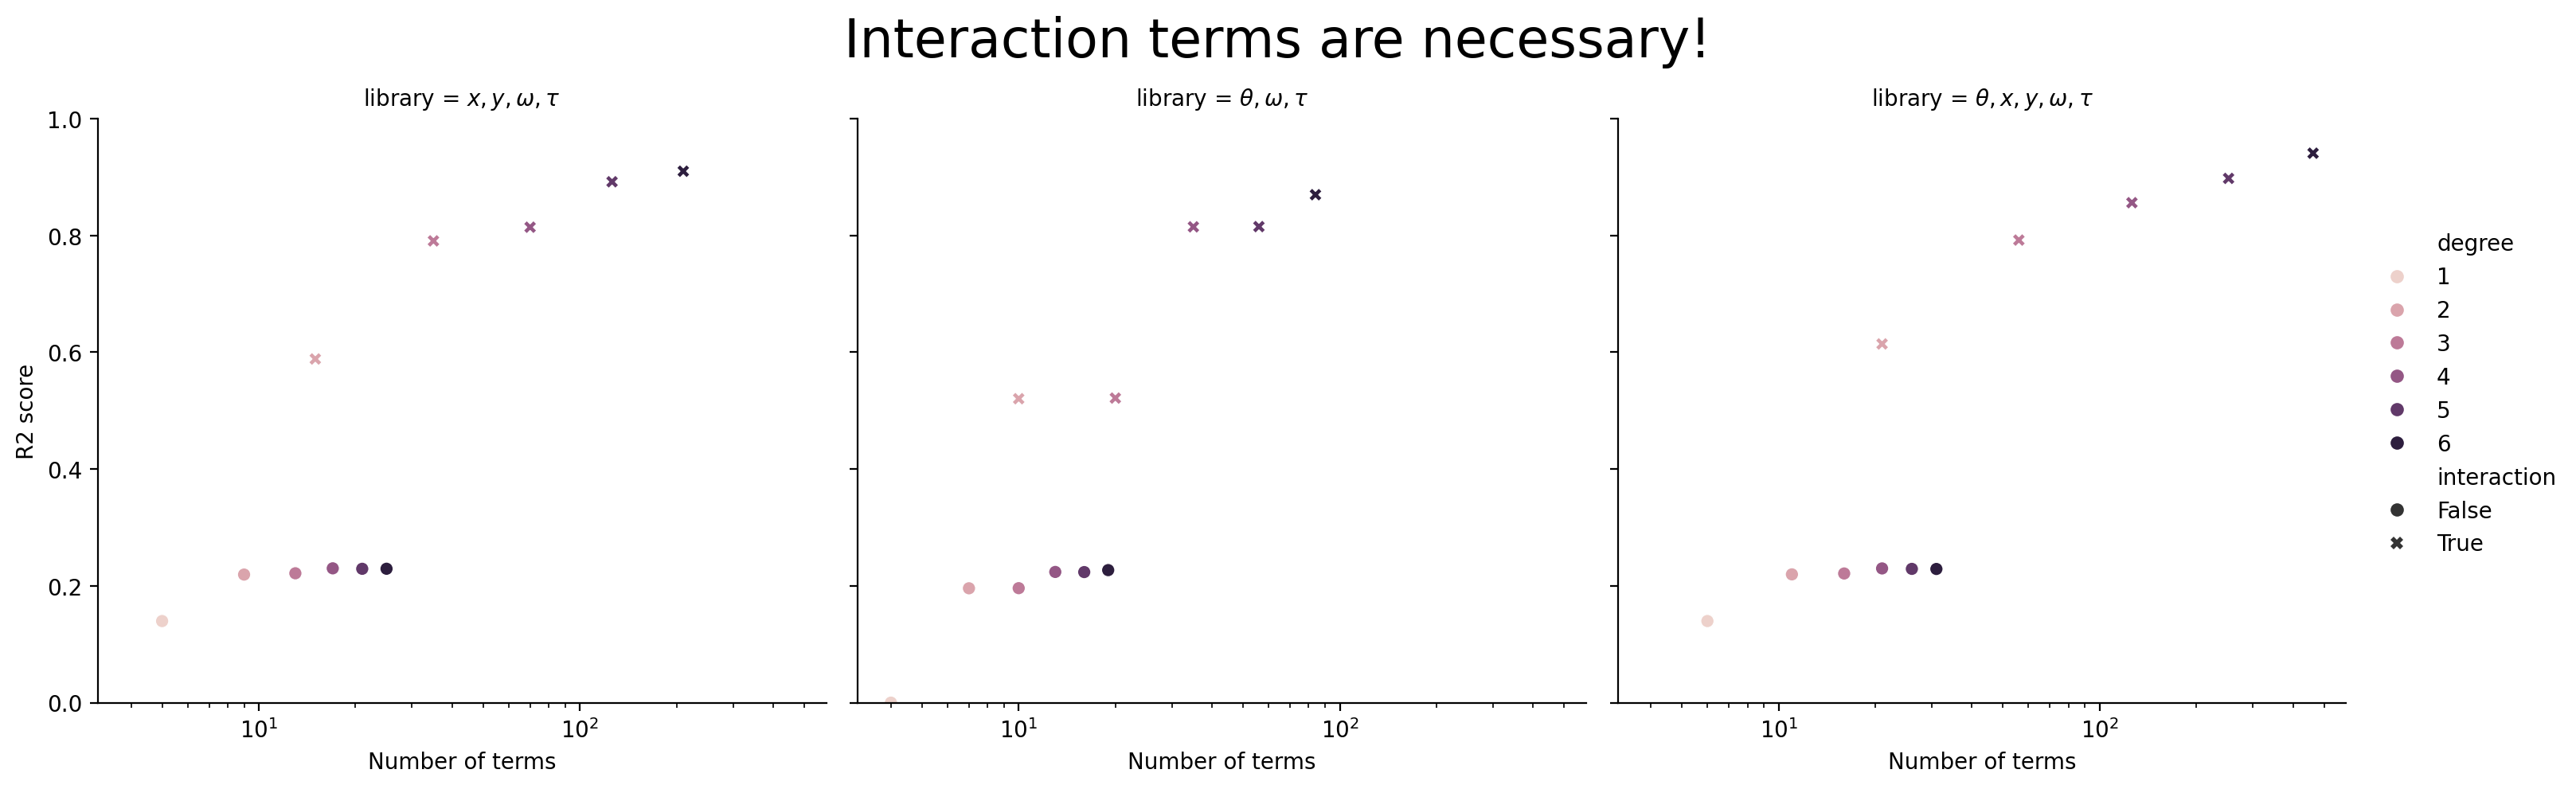

In [348]:
import seaborn as sns

p = sns.relplot(
    data=results,
    kind='scatter',
    col='library',
    x='num_terms',
    y='score',
    hue='degree',
    style='interaction'
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score')
p.figure.suptitle('Interaction terms are necessary!', size=24)
p.figure.subplots_adjust(top=0.85)
#sns.move_legend(ax, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)

In [349]:
# Let's do a parameter sweep
import pandas as pd
results = pd.DataFrame(columns=['degree', 'interaction', 'score', 'num_terms', 'library'])

inputs = np.concatenate([states, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_states, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

threshold=1e0
alpha=1e3

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$x, y, \\omega, \\tau$']

inputs = np.concatenate([theta, omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, \\omega, \\tau$']

inputs = np.concatenate([theta, np.cos(theta), np.sin(theta), omega, actions], axis=1)
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

test_inputs = np.concatenate([test_theta, np.cos(test_theta), np.sin(test_theta), test_omega, test_actions], axis=1)
test_targets = agent.critic_model1(test_states, test_actions, training=False).numpy().reshape([-1, 1])

for degree in range(1, 7):
    for interaction in [True]:
        sindy = ps.SINDy(
            feature_library=ps.PolynomialLibrary(degree=degree, include_bias=True, include_interaction=interaction),
            optimizer=ps.STLSQ(threshold=threshold, alpha=alpha, normalize_columns=True),
            feature_names=['th', 'x,', 'y', 'w', 'T']
        )
        sindy.fit(x=inputs, x_dot=targets)
        test_score = sindy.score(x=test_inputs, x_dot=test_targets)
        num_terms = np.count_nonzero(sindy.coefficients())
        results.loc[len(results)] = [degree, interaction, test_score, num_terms, '$\\theta, x, y, \\omega, \\tau$']

results


(10000, 4) (10000, 1)
(10000, 3) (10000, 1)
(10000, 5) (10000, 1)


,degree,interaction,score,num_terms,library
0,1,True,0.139828,2,"$x, y, \omega, \tau$"
1,2,True,0.586334,7,"$x, y, \omega, \tau$"
2,3,True,0.587514,10,"$x, y, \omega, \tau$"
3,4,True,0.615079,24,"$x, y, \omega, \tau$"
4,5,True,0.615032,28,"$x, y, \omega, \tau$"
5,6,True,0.628818,58,"$x, y, \omega, \tau$"
6,1,True,0.000059,2,"$\theta, \omega, \tau$"
7,2,True,0.283651,6,"$\theta, \omega, \tau$"
8,3,True,0.401209,10,"$\theta, \omega, \tau$"
9,4,True,0.787577,18,"$\theta, \omega, \tau$"


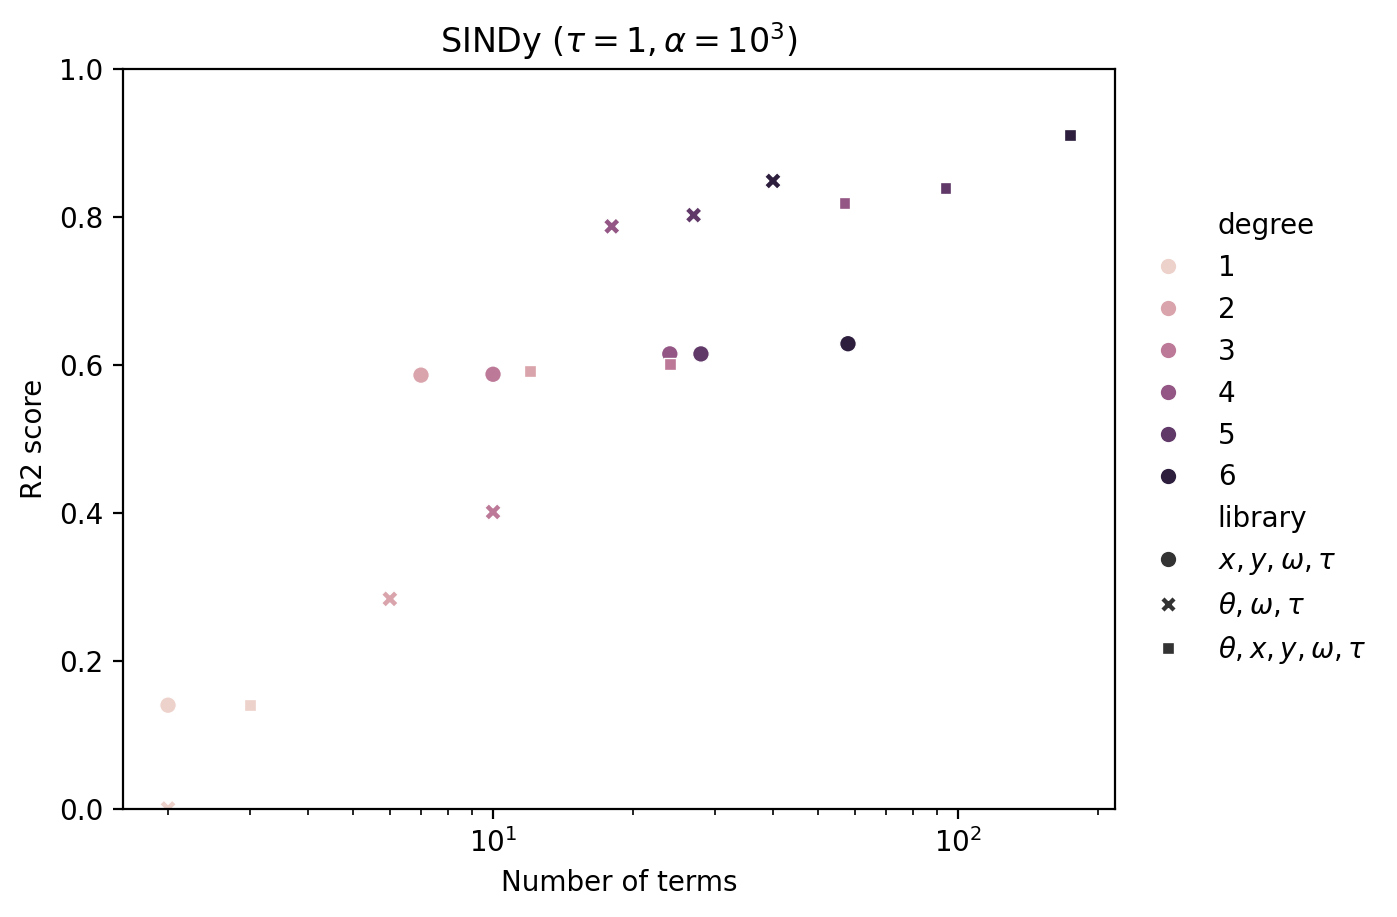

In [350]:
import seaborn as sns
plt.rcParams['figure.dpi'] = 200
p = sns.scatterplot(
    data=results[results.interaction],
    x='num_terms',
    y='score',
    hue='degree',
    style='library',
)
p.set(xscale='log', ylim=[0, 1])
p.set(xlabel='Number of terms', ylabel='R2 score', title='SINDy ($\\tau=1, \\alpha=10^3$)')
sns.move_legend(p, loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0)